In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import random
from prettytable import PrettyTable
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
import pywt
from scipy.interpolate import interp1d
from torchinfo import summary
import tqdm

In [233]:
# 讀取資料 (2019/10/30 - 2024/11/29)

df = pd.read_csv('UMC_final_data3.csv', index_col=0)

df.index = pd.to_datetime(df.index)

df.head()

,up_down,Open,High,Low,Close,Volume,Turnover rate,Market capitalization,ln_past_return,PE ratio,...,Commercial_Paper_Rate,10Y_Gov_Bond_Rate,Overall_Index,Food,Clothing,Housing,Transport_Communication,Healthcare,Education_Recreation,Miscellaneous
年月日,,,,,,,,,,,,,,,,,,,,,
2019-10-30,0,14.70,14.70,14.35,14.40,61233,0.5223,168830,-0.6920,45.5349,...,0.57,0.70,98.75,98.52,104.15,98.50,97.03,99.15,99.97,98.24
2019-10-31,0,14.35,14.35,13.90,14.00,97117,0.8283,164140,-2.8171,44.2700,...,0.57,0.70,98.75,98.52,104.15,98.50,97.03,99.15,99.97,98.24
2019-11-01,1,14.15,14.55,14.10,14.50,93849,0.8005,170003,3.5091,45.8511,...,0.54,0.69,98.35,97.64,101.73,98.49,96.95,99.39,99.29,98.37
2019-11-04,1,14.50,14.80,14.50,14.65,94378,0.8050,171761,1.0292,46.3254,...,0.54,0.69,98.35,97.64,101.73,98.49,96.95,99.39,99.29,98.37
2019-11-05,0,14.65,14.70,14.40,14.50,53488,0.4562,170003,-1.0292,45.8511,...,0.54,0.69,98.35,97.64,101.73,98.49,96.95,99.39,99.29,98.37


In [108]:
# 檢查是否有可用的 GPU
print(torch.cuda.is_available())
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

if device.type == 'cuda':
    # 獲取當前 GPU 的 ID
    current_device = torch.cuda.current_device()

    # 獲取當前 GPU 的名稱
    device_name = torch.cuda.get_device_name(current_device)

    print(f'Using device: {device}')
    print(f"Current device ID: {current_device}")
    print(f"Current device name: {device_name}")

True


In [234]:
ln_return_np = df['ln_past_return']
ln_return = pd.DataFrame(ln_return_np, columns=['ln_past_return'])

ln_return.head()

,ln_past_return
年月日,
2019-10-30,-0.6920
2019-10-31,-2.8171
2019-11-01,3.5091
2019-11-04,1.0292
2019-11-05,-1.0292


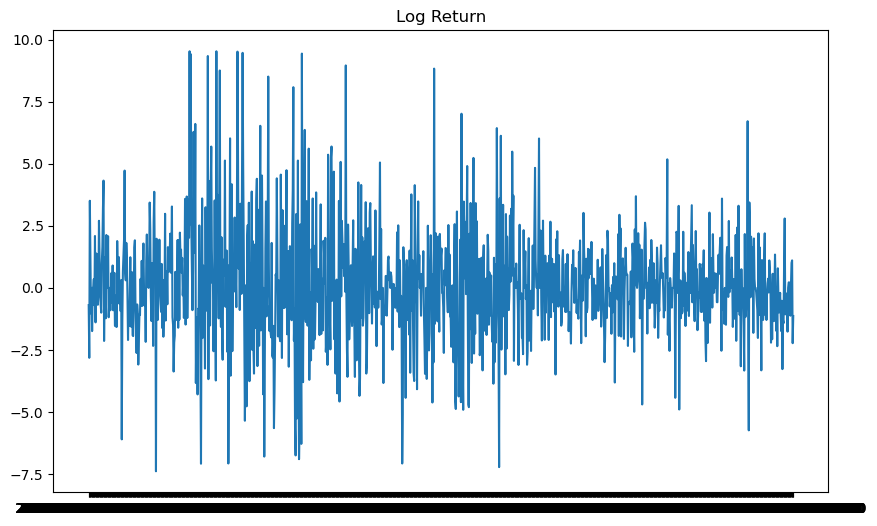

In [83]:
plt.figure(figsize=(10, 6))
plt.plot(ln_return)
plt.title('Log Return')
plt.show()

In [235]:
predict_length = np.sum(ln_return.index >= '2024-06-01')
train_log_return = ln_return[ln_return.index < '2024-06-01']
train_log_return_np = train_log_return.to_numpy()
print(f"train_log_return_np.shape: {train_log_return_np.shape}")

train_log_return_np.shape: (1116, 1)


In [74]:
def sliding_window(data, window_size):

    window = np.zeros((data.shape[0] - window_size + 1, window_size, data.shape[1]))

    for i in range(data.shape[0] - window_size + 1):
        window[i] = data[i:i + window_size]

    return window

n_step = 25 + 1 

In [80]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_layer_size=32, num_layers=2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True, num_layers=num_layers)
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        # input_seq: (batch_size, seq_len, input_size)

        h0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(device)
        c0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(device)

        out, _ = self.lstm(input_seq, (h0, c0)) # out: (batch_size, seq_len, hidden_layer_size)
        out = self.dropout(out[:, -1, :])       # out: (batch_size, hidden_layer_size)
        out = self.fc(out)                      # out: (batch_size, output_size)

        return out

## 開始 5-CV 程式碼

In [ ]:
## 計算 CV 切點

total = 1091
fold_points = [int(np.round(total * i / 5)) for i in range(1, 5)] + [1091]

print(fold_points)

[218, 436, 655, 873, 1091]


In [ ]:
from collections import defaultdict

wavelets = [f"db{i}" for i in range(1, 39, 1)]  
nfold = 4
window_size = 25 + 1
best_wavelet = None
best_mse = float('inf')
best_train_loss_history = []
best_val_loss_history = []
best_test_loss = None

# Early stopping parameters
patience = 200  
min_delta = 0.05  

wavelet_results2 = defaultdict(lambda: {"train_mse": [], "val_mse": [], "val_fold_mse": [], "val_mse_true": [], "val_fold_mse_true": []})

for wavelet in wavelets:
    print(f"Processing Wavelet: {wavelet}")
    fold_train_losses = []  
    fold_val_losses = []  
    fold_val_losses_true = []  
    fold_val_details = []
    fold_val_details_true = []  

    for k in range(nfold):

        X = ln_return[:fold_points[k + 1] + 25].squeeze()
        coeffs = pywt.wavedec(X, wavelet)
        zero_filled_coeffs = coeffs[:-1] + [np.zeros_like(coeffs[-1])]
        denoised_data = pywt.waverec(zero_filled_coeffs, wavelet)
        denoised_data = pd.DataFrame(denoised_data[: len(X)])

        log_return_window = sliding_window(denoised_data.to_numpy(), window_size)
        log_return_tensor = torch.tensor(log_return_window, dtype=torch.float32).to(device)

        true_log_return_window = sliding_window(ln_return[:fold_points[k + 1] + 25].to_numpy(), window_size)
        true_log_return_tensor = torch.tensor(true_log_return_window, dtype=torch.float32).to(device)

        X_train = log_return_tensor[:fold_points[k], :-1]
        y_train = log_return_tensor[:fold_points[k], -1]

        X_val = log_return_tensor[fold_points[k]:, :-1]
        y_val = log_return_tensor[fold_points[k]:, -1]
        y_val_true = true_log_return_tensor[fold_points[k]:, -1]

        LSTM_model = LSTM(input_size=1, output_size=1, hidden_layer_size=8).to(device)
        optimizer = torch.optim.Adam(LSTM_model.parameters(), lr=0.001)
        loss_function = nn.MSELoss()

        torch.manual_seed(2303)
        # 
        train_loss_history = []
        val_loss_history = []
        val_loss_history_true = []
        num_epochs = 2000
        early_stopping_counter = 0
        best_fold_val_loss = float('inf')  
        bar = tqdm.tqdm(range(num_epochs), desc=f"Wavelet {wavelet} Fold {k+1}")

        for _ in bar:
            LSTM_model.train()
            optimizer.zero_grad()
            y_pred = LSTM_model(X_train)
            train_loss = loss_function(y_pred, y_train)
            train_loss.backward()
            optimizer.step()
            train_loss_history.append(train_loss.item())

            LSTM_model.eval()
            with torch.no_grad():
                y_val_pred = LSTM_model(X_val)
                val_loss = loss_function(y_val_pred, y_val)
                val_loss_true = loss_function(y_val_pred, y_val_true)
                val_loss_history.append(val_loss.item())
                val_loss_history_true.append(val_loss_true.item())

            bar.set_postfix(train_loss=train_loss.item(), val_loss=val_loss.item(), val_loss_true=val_loss_true.item())

            if val_loss.item() < best_fold_val_loss - min_delta:
                best_fold_val_loss = val_loss.item()
                early_stopping_counter = 0
            else:
                early_stopping_counter += 1

            if early_stopping_counter >= patience:
                print(f"Early stopping triggered for Wavelet {wavelet} Fold {k+1} at Epoch {_+1}")
                break

        fold_train_losses.append(train_loss.item())
        fold_val_losses.append(val_loss.item())
        fold_val_losses_true.append(val_loss_true.item())
        fold_val_details.append(val_loss.item())
        fold_val_details_true.append(val_loss_true.item())

    avg_train_loss = np.mean(fold_train_losses)
    avg_val_loss = np.mean(fold_val_losses)
    avg_val_loss_true = np.mean(fold_val_losses_true)
    wavelet_results2[wavelet]["train_mse"] = avg_train_loss
    wavelet_results2[wavelet]["val_mse"] = avg_val_loss
    wavelet_results2[wavelet]["val_fold_mse"] = fold_val_details
    wavelet_results2[wavelet]["val_mse_true"] = avg_val_loss_true
    wavelet_results2[wavelet]["val_fold_mse_true"] = fold_val_details_true  

    if avg_val_loss_true < best_mse:
        best_mse = avg_val_loss_true
        best_wavelet = wavelet
        best_train_loss = avg_train_loss

print("\nWavelet Validation Results:")
for wavelet, results in wavelet_results2.items():
    print(f"Wavelet {wavelet}: Average Train MSE = {results['train_mse']:.4f}, Average Validation MSE = {results['val_mse_true']:.4f}")
    print(f"  Validation Fold Results: {results['val_fold_mse_true']}")

print(f"\nBest Wavelet: {best_wavelet}")
print(f"Best Average Train MSE: {best_train_loss:.4f}, Average Validation MSE: {best_mse:.4f}")

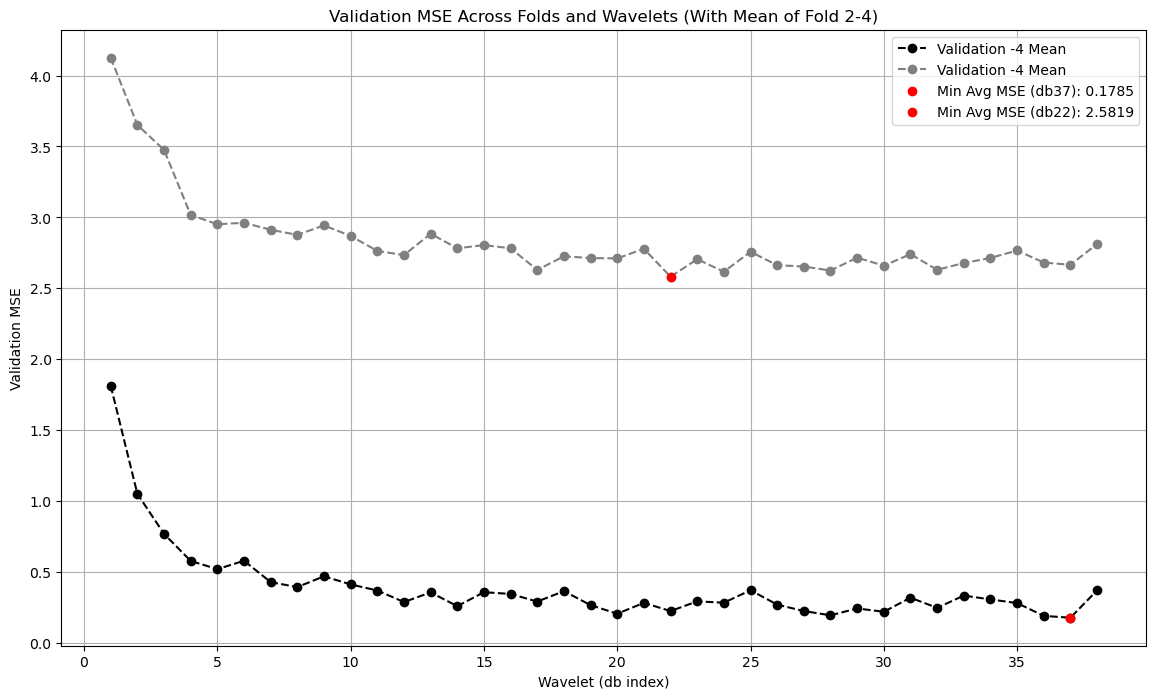

In [ ]:
wavelet_ids = range(1, 39)

plt.figure(figsize=(14, 8))

val_mean_mse_true = [
    np.mean([wavelet_results2[f"db{i}"]["val_fold_mse_true"][0],
             wavelet_results2[f"db{i}"]["val_fold_mse_true"][1],  
             wavelet_results2[f"db{i}"]["val_fold_mse_true"][2], 
             wavelet_results2[f"db{i}"]["val_fold_mse_true"][3]]) 
    for i in wavelet_ids
]

val_mean_mse = [
    np.mean([wavelet_results2[f"db{i}"]["val_fold_mse"][0],
             wavelet_results2[f"db{i}"]["val_fold_mse"][1],  
             wavelet_results2[f"db{i}"]["val_fold_mse"][2],  
             wavelet_results2[f"db{i}"]["val_fold_mse"][3]]) 
    for i in wavelet_ids
]

plt.plot(wavelet_ids, val_mean_mse, label="Validation -4 Mean", marker='o', linestyle='--', color='black')
plt.plot(wavelet_ids, val_mean_mse_true, label="Validation -4 Mean", marker='o', linestyle='--', color='gray')

min_mse = min(val_mean_mse)
min_mse_idx = wavelet_ids[val_mean_mse.index(min_mse)]
plt.scatter(min_mse_idx, min_mse, color='red', label=f"Min Avg MSE (db{min_mse_idx}): {min_mse:.4f}", zorder=5)

min_mse_true = min(val_mean_mse_true)
min_mse_idx_true = wavelet_ids[val_mean_mse_true.index(min_mse_true)]
plt.scatter(min_mse_idx_true, min_mse_true, color='red', label=f"Min Avg MSE (db{min_mse_idx_true}): {min_mse_true:.4f}", zorder=5)

plt.xlabel("Wavelet (db index)")
plt.ylabel("Validation MSE")
plt.title("Validation MSE Across Folds and Wavelets (With Mean of Fold 2-4)")
plt.legend()
plt.grid()
plt.show()


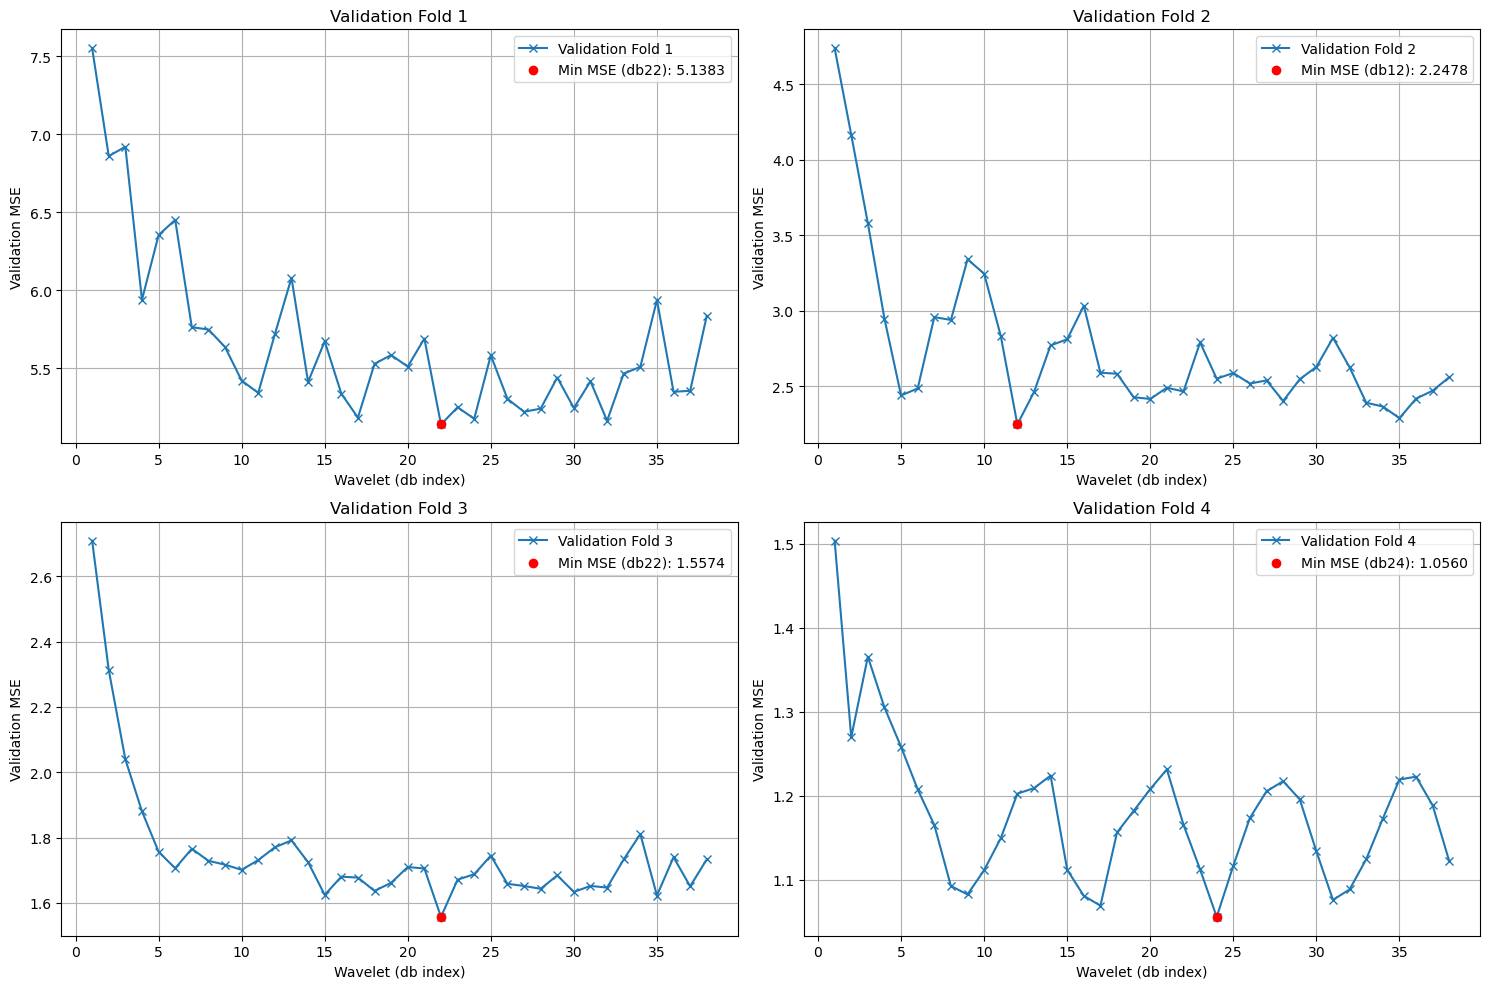

In [ ]:
wavelet_ids = range(1, 39)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for k in range(nfold):
    ax = axes[k]
    
    val_fold_mse = [wavelet_results2[f"db{i}"]["val_fold_mse_true"][k] for i in wavelet_ids]
    
    ax.plot(wavelet_ids, val_fold_mse, label=f"Validation Fold {k+1}", marker='x', linestyle='-')
    
    min_mse = min(val_fold_mse)
    min_mse_idx = wavelet_ids[val_fold_mse.index(min_mse)]
    ax.scatter(min_mse_idx, min_mse, color='red', label=f"Min MSE (db{min_mse_idx}): {min_mse:.4f}", zorder=5)
    
    ax.set_xlabel("Wavelet (db index)")
    ax.set_ylabel("Validation MSE")
    ax.set_title(f"Validation Fold {k+1}")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()


## db22

In [163]:
## 試試看 小波降噪後是否還有這樣的問題

wavelet = 'db22' 
coeffs = pywt.wavedec(ln_return.squeeze(), wavelet)

zero_filled_coeffs = coeffs[:-1] + [np.zeros_like(coeffs[-1])]

denoised_data = pywt.waverec(zero_filled_coeffs, wavelet)

denoised_data = denoised_data[:len(ln_return.squeeze())]

denoised_data = pd.DataFrame(denoised_data)


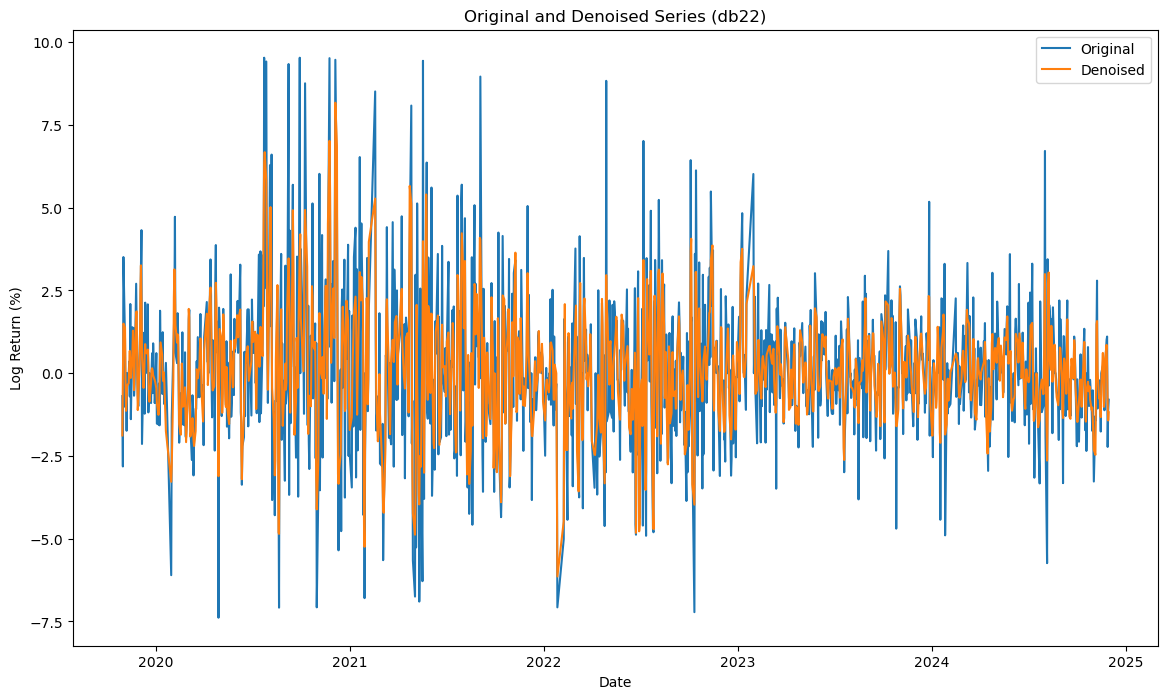

In [164]:
plt.figure(figsize=(14, 8))
plt.plot(df.index, ln_return_np, label='Original')
plt.plot(df.index, denoised_data, label='Denoised')
plt.title('Original and Denoised Series (db22)')
plt.xlabel('Date')
plt.ylabel('Log Return (%)')
plt.legend()
plt.show()

In [179]:
predict_length = np.sum(ln_return.index >= '2024-06-01')
train_log_return = denoised_data[:1116]
train_log_return_np = train_log_return.to_numpy()
print(f"train_log_return_np.shape: {train_log_return_np.shape}")

train_log_return_np.shape: (1116, 1)


In [180]:
train_log_return_window = sliding_window(train_log_return_np, n_step)
train_log_return_tensor = torch.tensor(train_log_return_window, dtype=torch.float32).to(device)
print(f"train_log_return_window.shape: {train_log_return_tensor.shape}")

train_log_return_window.shape: torch.Size([1091, 26, 1])


In [181]:
# 整條切 sliding window

log_return_window = sliding_window(denoised_data.to_numpy(), n_step)
log_return_tensor = torch.tensor(log_return_window, dtype=torch.float32).to(device)
print(f"log_return_window.shape: {log_return_tensor.shape}")

log_return_window.shape: torch.Size([1213, 26, 1])


In [182]:
true_log_return_window = sliding_window(ln_return.to_numpy(), n_step)
true_log_return_tensor = torch.tensor(true_log_return_window, dtype=torch.float32).to(device)
print(f"log_return_window.shape: {true_log_return_tensor.shape}")

log_return_window.shape: torch.Size([1213, 26, 1])


In [203]:
x_train_full = train_log_return_tensor[:, :-1]
y_train_full = train_log_return_tensor[:, -1]
y_train_true = true_log_return_tensor[:1091, -1]
y_true = true_log_return_tensor[:, -1]
print(f"x_train_full.shape: {x_train_full.shape}, y_train_full.shape: {y_train_full.shape}, y_train_true.shape: {y_train_true.shape}")

x_train_full.shape: torch.Size([1091, 25, 1]), y_train_full.shape: torch.Size([1091, 1]), y_train_true.shape: torch.Size([1091, 1])


In [210]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=2303, shuffle=False
)

In [211]:
x_log_return = log_return_tensor[:, :-1]
y_log_return = log_return_tensor[:, -1]
print(f"x_log_return.shape: {x_log_return.shape}, y_log_return.shape: {y_log_return.shape}")

x_log_return.shape: torch.Size([1213, 25, 1]), y_log_return.shape: torch.Size([1213, 1])


In [212]:
x_test = log_return_tensor[1091:, :-1]
y_test = true_log_return_tensor[1091:, -1]
print(f"x_log_return.shape: {x_test.shape}, y_log_return.shape: {y_test.shape}")

x_log_return.shape: torch.Size([122, 25, 1]), y_log_return.shape: torch.Size([122, 1])


In [213]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_layer_size=32, num_layers=2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True, num_layers=num_layers)
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        # input_seq: (batch_size, seq_len, input_size)

        h0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(device)
        c0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(device)

        out, _ = self.lstm(input_seq, (h0, c0)) # out: (batch_size, seq_len, hidden_layer_size)
        out = self.dropout(out[:, -1, :])       # out: (batch_size, hidden_layer_size)
        out = self.fc(out)                      # out: (batch_size, output_size)

        return out

In [214]:
learning_rate = 0.001

LSTM_model = LSTM(input_size=1, output_size=1, num_layers=2).to(device)
optimizer = torch.optim.Adam(LSTM_model.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()

In [215]:
summary(LSTM_model, input_data=x_train)

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [872, 1]                  --
├─LSTM: 1-1                              [872, 25, 32]             12,928
├─Dropout: 1-2                           [872, 32]                 --
├─Linear: 1-3                            [872, 1]                  33
Total params: 12,961
Trainable params: 12,961
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 281.86
Input size (MB): 0.09
Forward/backward pass size (MB): 5.59
Params size (MB): 0.05
Estimated Total Size (MB): 5.73

In [ ]:
torch.manual_seed(2303)
num_epochs = 2000
patience = 200 
min_delta = 0.005  
early_stopping_counter = 0  
best_val_loss = float('inf')  

train_loss_history = []
val_loss_history = []
test_loss_history = []

bar = tqdm.tqdm(range(num_epochs), desc="Training Progress")

for epoch in bar:
    
    LSTM_model.train()
    y_pred = LSTM_model(x_train)

    
    loss = loss_function(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss_history.append(loss.item())

    
    LSTM_model.eval()
    with torch.no_grad():
        y_val_pred = LSTM_model(x_val)
        val_loss = loss_function(y_val_pred, y_val)
        val_loss_history.append(val_loss.item())

  
        y_test_pred = LSTM_model(x_test)
        test_loss = loss_function(y_test_pred, y_test)
        test_loss_history.append(test_loss.item())

    bar.set_postfix(
        train_loss=loss.item(),
        val_loss=val_loss.item(),
        test_loss=test_loss.item()
    )

    if val_loss.item() < best_val_loss - min_delta:
        best_val_loss = val_loss.item()
        early_stopping_counter = 0  
    else:
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

final_train_loss = train_loss_history[-1]
final_val_loss = val_loss_history[-1]
final_test_loss = test_loss_history[-1]

print("\nTraining Completed.")
print(f"Final Train Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Test Loss: {final_test_loss:.4f}")


Training Progress:  27%|██▋       | 547/2000 [00:15<00:40, 35.76it/s, test_loss=1.5, train_loss=0.0894, val_loss=0.0114] 

Early stopping triggered at epoch 548

Training Completed.
Final Train Loss: 0.0894
Final Validation Loss: 0.0114
Final Test Loss: 1.4979


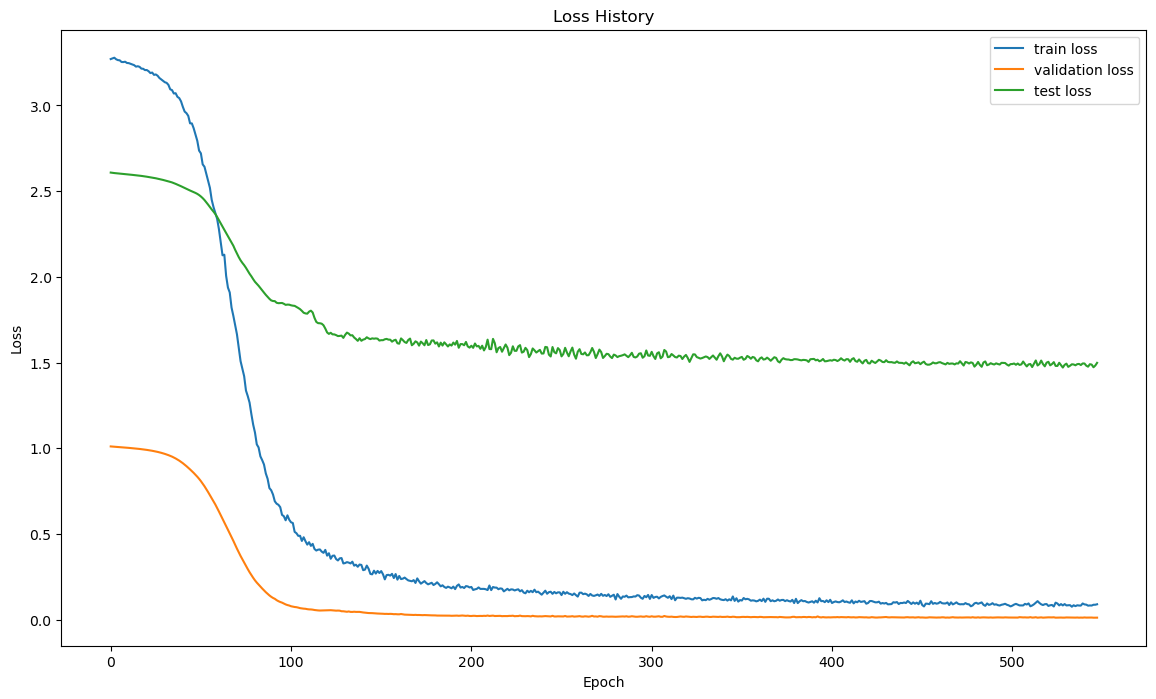

In [217]:
plt.figure(figsize=(14, 8))

plt.plot(train_loss_history , label = "train loss")
plt.plot(val_loss_history , label = "validation loss")
plt.plot(test_loss_history , label = "test loss")
plt.legend()
plt.title("Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

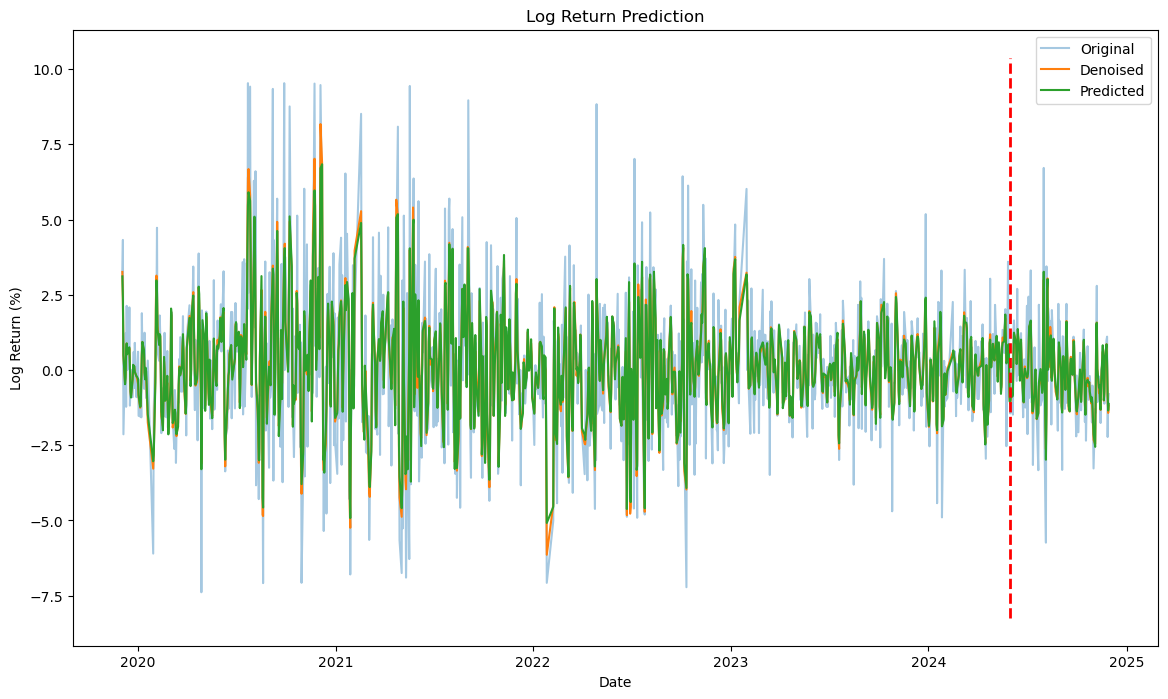

In [218]:
plt.figure(figsize=(14, 8))

LSTM_model.eval()
with torch.no_grad():
    y_pred = LSTM_model(x_log_return)

plt.plot(df.index[n_step-1:], y_true, label='Original', alpha=0.4)
plt.plot(df.index[n_step-1:], y_log_return, label='Denoised')
plt.plot(df.index[n_step-1:], y_pred, label='Predicted')
plt.title('Log Return Prediction')
plt.xlabel('Date')
plt.ylabel('Log Return (%)')
ymin, ymax = plt.ylim()
plt.vlines(df.index[-predict_length-1:-predict_length], ymin, ymax, color="red", linestyles="dashed", linewidth=2)
plt.legend()
plt.show()

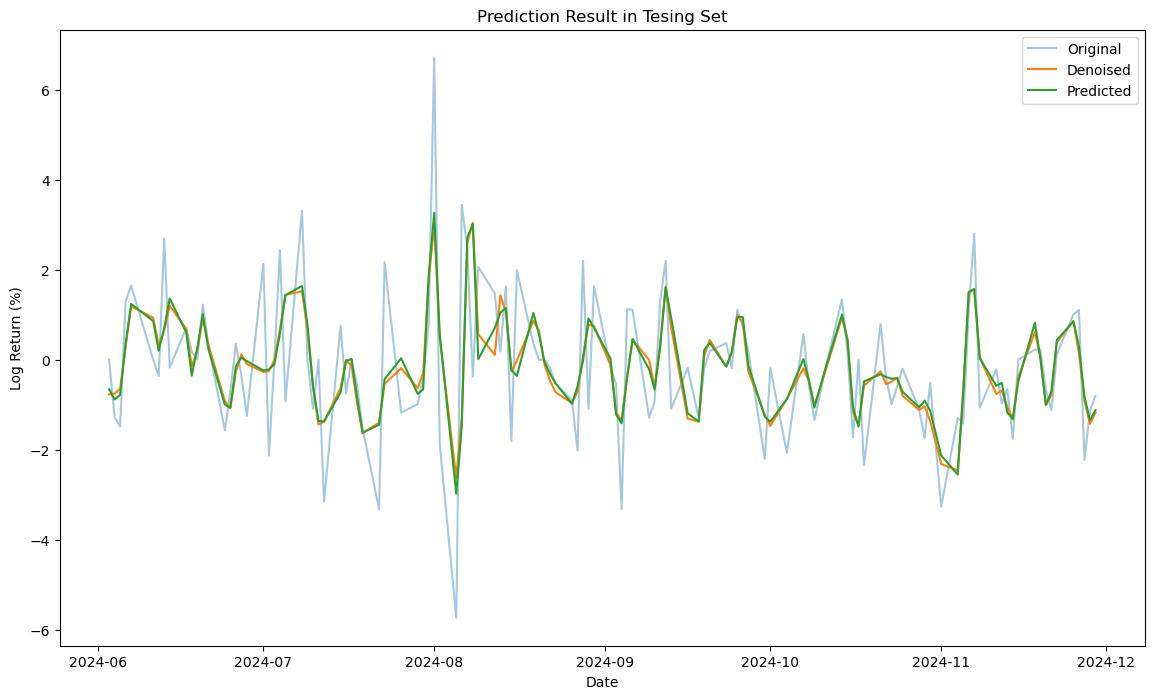

In [219]:
plt.figure(figsize=(14, 8))

plt.plot(df.index[-predict_length:], y_true[1091:], label='Original', alpha = 0.4)
plt.plot(df.index[-predict_length:], y_log_return[1091:], label='Denoised')
plt.plot(df.index[-predict_length:], y_pred[1091:], label='Predicted')
plt.title('Prediction Result in Tesing Set')
plt.xlabel('Date')
plt.ylabel('Log Return (%)')
plt.legend()
plt.show()

In [220]:
test_mse = final_test_loss
test_rmse = np.sqrt(test_mse)
test_mse, test_rmse

(1.4979033470153809, 1.223888617078932)

## 轉回股價

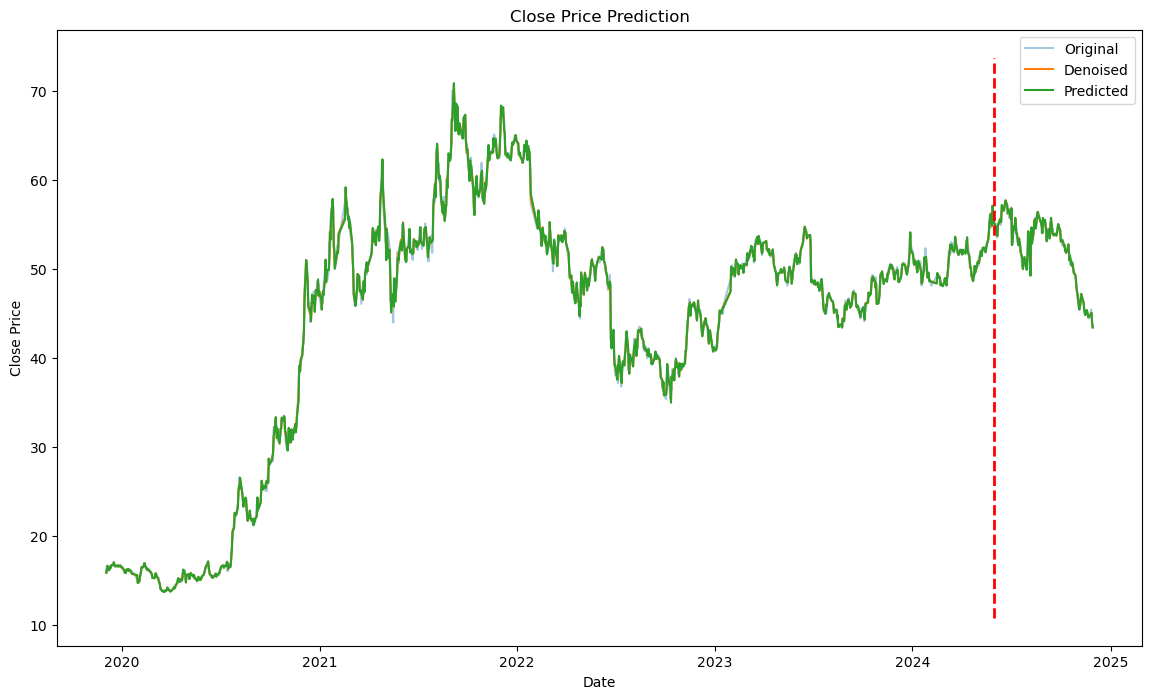

In [221]:
LSTM_model.eval()
with torch.no_grad():
    y_pred = LSTM_model(x_log_return).cpu().numpy().squeeze()

close_price = df['Close'].values

# Ct = Ct-1*exp(0.01*Rt_hat)
close_price_pred = close_price[n_step-2:-1]*np.exp(0.01*y_pred)
close_price_filtered = close_price[n_step-2:-1]*np.exp(0.01*denoised_data[n_step-1:].squeeze().values)

# 原始索引
original_index = df.index[n_step-2:-1]

plt.figure(figsize=(14, 8))
plt.plot(df.index[n_step-1:], close_price[n_step-1:], label='Original', alpha=0.4)
plt.plot(df.index[n_step-1:], close_price_filtered, label='Denoised')
plt.plot(df.index[n_step-1:], close_price_pred, label='Predicted')
plt.title('Close Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
ymin, ymax = plt.ylim()
plt.vlines(df.index[-predict_length-1:-predict_length], ymin, ymax, color="red", linestyles="dashed", linewidth=2)
plt.legend()
plt.show()

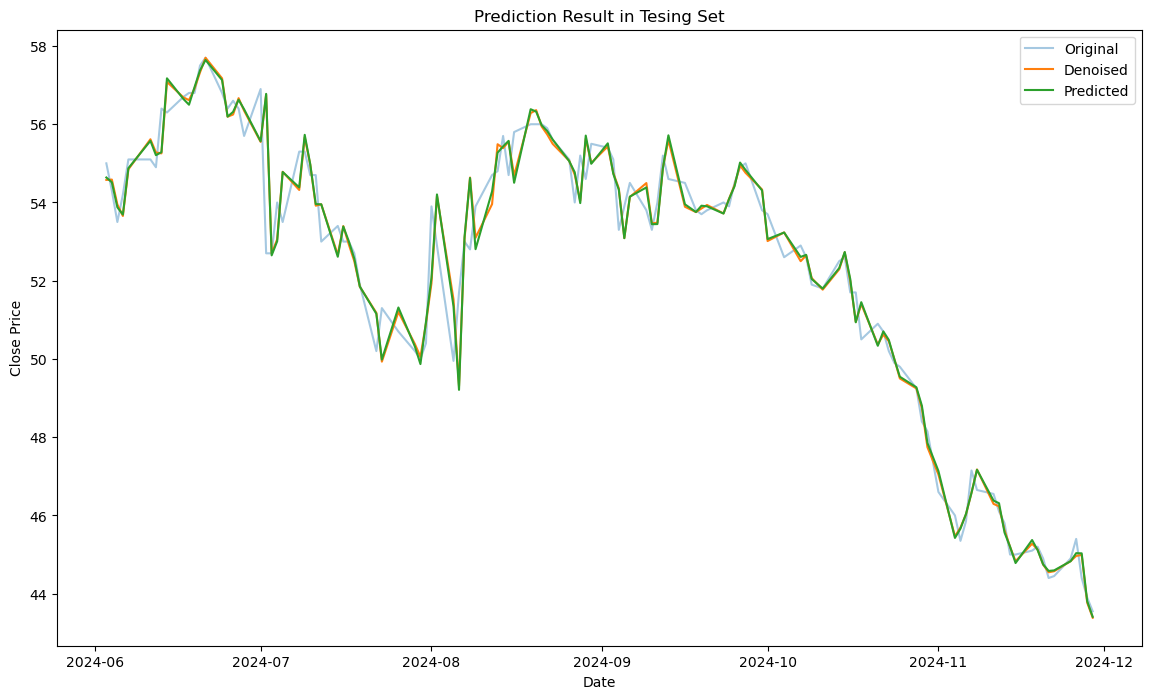

In [222]:
plt.figure(figsize=(14, 8))
plt.plot(df.index[-predict_length:], close_price[-predict_length:], label='Original', alpha=0.4)
plt.plot(df.index[-predict_length:], close_price_filtered[-predict_length:], label='Denoised')
plt.plot(df.index[-predict_length:], close_price_pred[-predict_length:], label='Predicted')
plt.title('Prediction Result in Tesing Set')
plt.xlabel('Date')
plt.ylabel('Close Price')
ymin, ymax = plt.ylim()
plt.legend()
plt.show()

## 二元分類

In [224]:
LSTM_model.eval()
with torch.no_grad():
    y_pred_train = LSTM_model(x_train_full).cpu().numpy().squeeze()
    y_pred_train_no_valid = LSTM_model(x_train).cpu().numpy().squeeze()
    y_pred_val = LSTM_model(x_val).cpu().numpy().squeeze()
    y_pred_test = LSTM_model(x_test).cpu().numpy().squeeze()
    


y_train_pred_binary = np.where(y_pred_train > 0, 1, 0)
y_train_log_return_binary = np.where(y_train_full > 0, 1, 0)

y_train_no_valid_pred_binary = np.where(y_pred_train_no_valid > 0, 1, 0)
y_train_no_valid_log_return_binary = np.where(y_train > 0, 1, 0)

y_val_pred_binary = np.where(y_pred_val > 0, 1, 0)
y_val_log_return_binary = np.where(y_val > 0, 1, 0)

y_test_pred_binary = np.where(y_pred_test > 0, 1, 0)
y_test_log_return_binary = np.where(y_test > 0, 1, 0)

In [ ]:
from sklearn.metrics import mean_squared_error, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

train_no_valid_accuracy = accuracy_score(y_train_no_valid_log_return_binary, y_train_no_valid_pred_binary)
train_no_valid_precision = precision_score(y_train_no_valid_log_return_binary, y_train_no_valid_pred_binary)
train_no_valid_recall = recall_score(y_train_no_valid_log_return_binary, y_train_no_valid_pred_binary)
train_no_valid_f1 = f1_score(y_train_no_valid_log_return_binary, y_train_no_valid_pred_binary)
train_no_valid_conf_matrix = confusion_matrix(y_train_no_valid_log_return_binary, y_train_no_valid_pred_binary)

val_accuracy = accuracy_score(y_val_log_return_binary, y_val_pred_binary)
val_precision = precision_score(y_val_log_return_binary, y_val_pred_binary)
val_recall = recall_score(y_val_log_return_binary, y_val_pred_binary)
val_f1 = f1_score(y_val_log_return_binary, y_val_pred_binary)
val_conf_matrix = confusion_matrix(y_val_log_return_binary, y_val_pred_binary)

train_accuracy = accuracy_score(y_train_log_return_binary, y_train_pred_binary)
train_precision = precision_score(y_train_log_return_binary, y_train_pred_binary)
train_recall = recall_score(y_train_log_return_binary, y_train_pred_binary)
train_f1 = f1_score(y_train_log_return_binary, y_train_pred_binary)
train_conf_matrix = confusion_matrix(y_train_log_return_binary, y_train_pred_binary)


test_accuracy = accuracy_score(y_test_log_return_binary, y_test_pred_binary)
test_precision = precision_score(y_test_log_return_binary, y_test_pred_binary)
test_recall = recall_score(y_test_log_return_binary, y_test_pred_binary)
test_f1 = f1_score(y_test_log_return_binary, y_test_pred_binary)
test_conf_matrix = confusion_matrix(y_test_log_return_binary, y_test_pred_binary)

print("訓練集表現：")
print(f"  Accuracy: {train_no_valid_accuracy:.4f}")
print(f"  Precision: {train_no_valid_precision:.4f}")
print(f"  Recall: {train_no_valid_recall:.4f}")
print(f"  F1 Score: {train_no_valid_f1:.4f}")

print("\n驗證集表現：")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall: {val_recall:.4f}")
print(f"  F1 Score: {val_f1:.4f}")

print("訓練+驗證集表現：")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall: {train_recall:.4f}")
print(f"  F1 Score: {train_f1:.4f}")

print("\n測試集表現：")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

訓練集表現：
  Accuracy: 0.9530
  Precision: 0.9562
  Recall: 0.9541
  F1 Score: 0.9552

驗證集表現：
  Accuracy: 0.9772
  Precision: 0.9826
  Recall: 0.9741
  F1 Score: 0.9784
訓練+驗證集表現：
  Accuracy: 0.9578
  Precision: 0.9615
  Recall: 0.9582
  F1 Score: 0.9599

測試集表現：
  Accuracy: 0.7541
  Precision: 0.6471
  Recall: 0.7333
  F1 Score: 0.6875


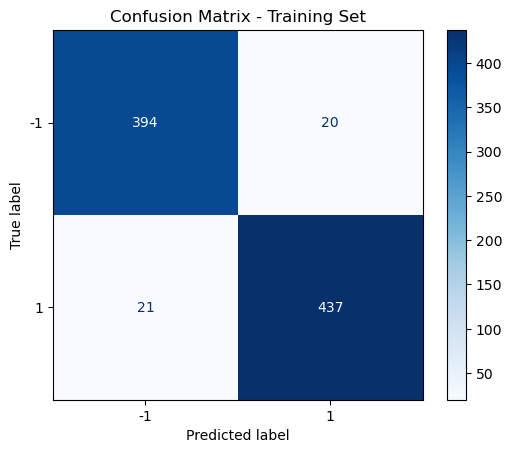

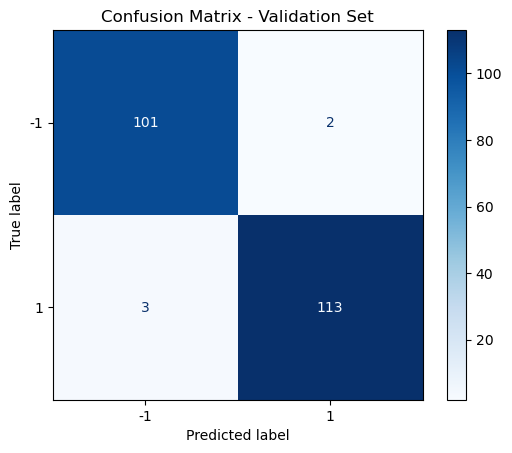

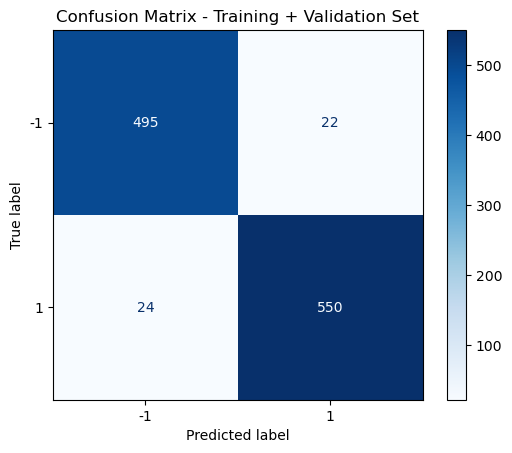

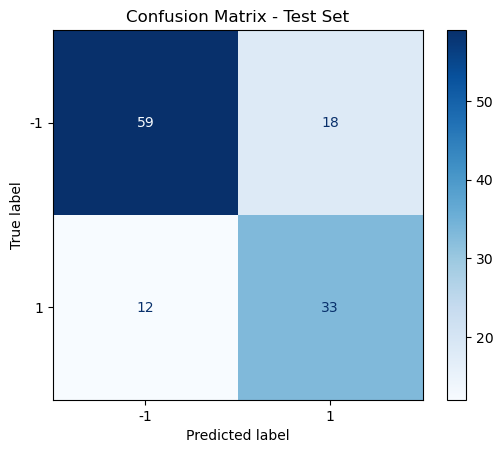

In [ ]:

def plot_confusion_matrix(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(train_no_valid_conf_matrix, title="Confusion Matrix - Training Set")


plot_confusion_matrix(val_conf_matrix, title="Confusion Matrix - Validation Set")

plot_confusion_matrix(train_conf_matrix, title="Confusion Matrix - Training + Validation Set")

plot_confusion_matrix(test_conf_matrix, title="Confusion Matrix - Test Set")

## 三元分類

In [240]:
scale = np.sqrt(np.var(denoised_data.squeeze().values)/np.var(ln_return_np))
scale

0.7211003843263694

In [242]:
shift = np.mean(denoised_data.squeeze().values)-np.mean(ln_return_np)
shift

-0.000113768054214064

In [ ]:
# 定義三類分界標準
def classify_three_classes(predictions, thresholds=(-0.7, 0.7)):
    lower, upper = thresholds
    return np.where(predictions > upper, 2,  # 大於上界為類別 2
           np.where(predictions <= lower, 0,  # 小於等於下界為類別 0
           1))  # 中間為類別 1



y_train_no_valid_pred_3class = classify_three_classes((y_pred_train_no_valid-shift)/scale)
y_train_no_valid_log_return_3class = classify_three_classes(y_train)

y_val_pred_3class = classify_three_classes((y_pred_val-shift)/scale)
y_val_log_return_3class = classify_three_classes(y_val)

y_train_pred_3class = classify_three_classes((y_pred_train-shift)/scale)
y_train_log_return_3class = classify_three_classes(y_train_full)

y_test_pred_3class = classify_three_classes((y_pred_test-shift)/scale)
y_test_log_return_3class = classify_three_classes(y_test)

In [ ]:

train_no_valid_accuracy = accuracy_score(y_train_no_valid_log_return_3class, y_train_no_valid_pred_3class)
train_no_valid_precision = precision_score(y_train_no_valid_log_return_3class, y_train_no_valid_pred_3class, average='macro')
train_no_valid_recall = recall_score(y_train_no_valid_log_return_3class, y_train_no_valid_pred_3class, average='macro')
train_no_valid_f1 = f1_score(y_train_no_valid_log_return_3class, y_train_no_valid_pred_3class, average='macro')
train_no_valid_conf_matrix = confusion_matrix(y_train_no_valid_log_return_3class, y_train_no_valid_pred_3class)


val_accuracy = accuracy_score(y_val_log_return_3class, y_val_pred_3class)
val_precision = precision_score(y_val_log_return_3class, y_val_pred_3class, average='macro')
val_recall = recall_score(y_val_log_return_3class, y_val_pred_3class, average='macro')
val_f1 = f1_score(y_val_log_return_3class, y_val_pred_3class, average='macro')
val_conf_matrix = confusion_matrix(y_val_log_return_3class, y_val_pred_3class)


train_accuracy = accuracy_score(y_train_log_return_3class, y_train_pred_3class)
train_precision = precision_score(y_train_log_return_3class, y_train_pred_3class, average='macro')
train_recall = recall_score(y_train_log_return_3class, y_train_pred_3class, average='macro')
train_f1 = f1_score(y_train_log_return_3class, y_train_pred_3class, average='macro')
train_conf_matrix = confusion_matrix(y_train_log_return_3class, y_train_pred_3class)



test_accuracy = accuracy_score(y_test_log_return_3class, y_test_pred_3class)
test_precision = precision_score(y_test_log_return_3class, y_test_pred_3class, average='macro')
test_recall = recall_score(y_test_log_return_3class, y_test_pred_3class, average='macro')
test_f1 = f1_score(y_test_log_return_3class, y_test_pred_3class, average='macro')
test_conf_matrix = confusion_matrix(y_test_log_return_3class, y_test_pred_3class)


print("訓練集表現：")
print(f"  Accuracy: {train_no_valid_accuracy:.4f}")
print(f"  Precision (Macro): {train_no_valid_precision:.4f}")
print(f"  Recall (Macro): {train_no_valid_recall:.4f}")
print(f"  F1 Score (Macro): {train_no_valid_f1:.4f}")

print("\n驗證集表現：")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Precision (Macro): {val_precision:.4f}")
print(f"  Recall (Macro): {val_recall:.4f}")
print(f"  F1 Score (Macro): {val_f1:.4f}")

print("訓練+驗證集表現：")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  Precision (Macro): {train_precision:.4f}")
print(f"  Recall (Macro): {train_recall:.4f}")
print(f"  F1 Score (Macro): {train_f1:.4f}")

print("\n測試集表現：")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision (Macro): {test_precision:.4f}")
print(f"  Recall (Macro): {test_recall:.4f}")
print(f"  F1 Score (Macro): {test_f1:.4f}")

訓練集表現：
  Accuracy: 0.9014
  Precision (Macro): 0.9081
  Recall (Macro): 0.9115
  F1 Score (Macro): 0.9002

驗證集表現：
  Accuracy: 0.8950
  Precision (Macro): 0.8846
  Recall (Macro): 0.9264
  F1 Score (Macro): 0.8973
訓練+驗證集表現：
  Accuracy: 0.9001
  Precision (Macro): 0.9038
  Recall (Macro): 0.9156
  F1 Score (Macro): 0.9007

測試集表現：
  Accuracy: 0.6066
  Precision (Macro): 0.6069
  Recall (Macro): 0.6078
  F1 Score (Macro): 0.6069


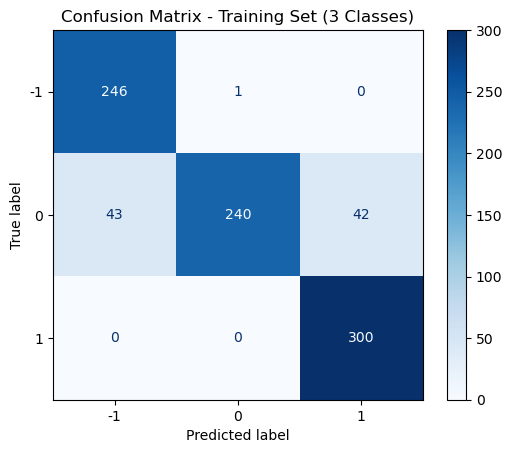

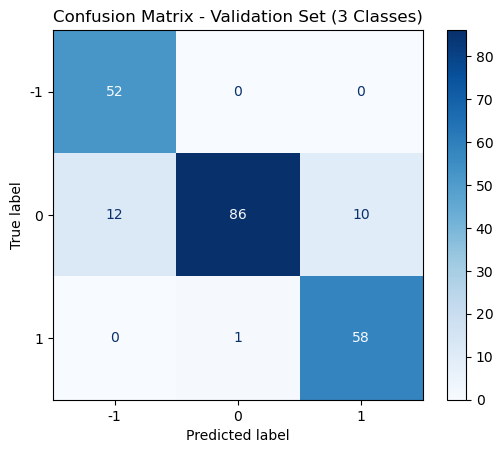

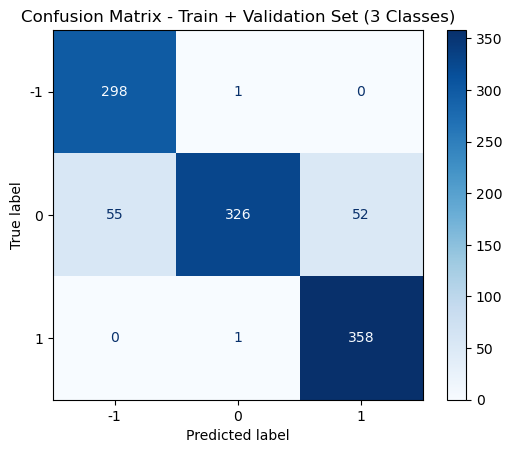

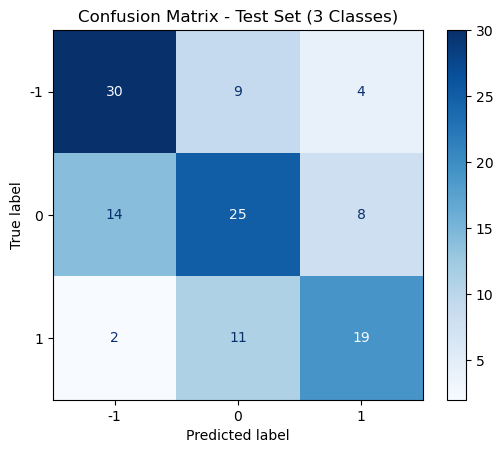

In [ ]:

def plot_confusion_matrix(cm, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


plot_confusion_matrix(train_no_valid_conf_matrix, title="Confusion Matrix - Training Set (3 Classes)")


plot_confusion_matrix(val_conf_matrix, title="Confusion Matrix - Validation Set (3 Classes)")


plot_confusion_matrix(train_conf_matrix, title="Confusion Matrix - Train + Validation Set (3 Classes)")


plot_confusion_matrix(test_conf_matrix, title="Confusion Matrix - Test Set (3 Classes)")